In [55]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import xgboost as xgb
import shap
import joblib
from scipy.stats import chi2_contingency, ttest_ind

In [56]:
data=pd.read_csv('medicine_dataset.csv')
data

C:\Users\mahes\AppData\Local\Temp\ipykernel_35448\597841669.py:1: DtypeWarning: Columns (42,43,44,45,46,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('medicine_dataset.csv')


,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,...,sideEffect41,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,...,NaN,Treatment of Cough with mucus,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,...,NaN,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,NaN,NaN,NaN,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,NaN,NaN,NaN,NaN,Sleepiness,Dryness in mouth,NaN,...,NaN,Treatment of Allergic conditions,NaN,NaN,NaN,NaN,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248213,248214,zestrain 100mg/325mg/250mg tablet mr,Aclotec MR 100mg/325mg/250mg Tablet,SAMONEC MR TABLET,Uniclof 100mg/325mg/250mg Tablet MR,Macito 100mg/325mg/250mg Tablet MR,Rumatin 100mg/325mg/250mg Tablet MR,Nausea,Vomiting,Heartburn,...,NaN,Treatment of Muscular pain,NaN,NaN,NaN,NaN,NaN,No,PAIN ANALGESICS,NaN
248214,248215,zoxinace 200mg tablet sr,Algic 200mg Tablet SR,Topnac 200mg Tablet SR,Kindac 200mg Tablet SR,Ultranac 200mg Tablet SR,Bignac 200mg Tablet SR,Dizziness,Indigestion,Nausea,...,NaN,Pain relief,NaN,NaN,NaN,NaN,Dichlorobenzenes Derivative,No,PAIN ANALGESICS,NSAID's- Non-Selective COX 1&2 Inhibitors (ace...
248215,248216,zivex 25mg tablet,HD Zine 25mg Tablet,Hydrocas 25mg Tablet,Hyzox 25 Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Sedation,Nausea,Vomiting,...,NaN,Treatment of Anxiety,Treatment of Skin conditions with inflammation...,NaN,NaN,NaN,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation)
248216,248217,zi fast 500mg injection,Zycin 500mg Injection,Aziwok 500mg Injection,Azirow 500mg Injection,Toracin 500mg Injection,Azymed 500mg Injection,"Injection site reactions (pain, swelling, redn...",Vomiting,Nausea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides


#### Changing from .csv to .parquet format to save memory and better efficiency

In [57]:
data.to_parquet('medicine_data.parquet',index=False)

In [58]:
df=pd.read_parquet('medicine_data.parquet')
df

,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,...,sideEffect41,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,None,Treatment of Bacterial infections,None,None,None,None,None,No,ANTI INFECTIVES,None
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,None,Treatment of Bacterial infections,None,None,None,None,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,...,None,Treatment of Cough with mucus,None,None,None,None,None,No,RESPIRATORY,None
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,...,None,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,None,None,None,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,None,None,None,None,Sleepiness,Dryness in mouth,None,...,None,Treatment of Allergic conditions,None,None,None,None,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248213,248214,zestrain 100mg/325mg/250mg tablet mr,Aclotec MR 100mg/325mg/250mg Tablet,SAMONEC MR TABLET,Uniclof 100mg/325mg/250mg Tablet MR,Macito 100mg/325mg/250mg Tablet MR,Rumatin 100mg/325mg/250mg Tablet MR,Nausea,Vomiting,Heartburn,...,None,Treatment of Muscular pain,None,None,None,None,None,No,PAIN ANALGESICS,None
248214,248215,zoxinace 200mg tablet sr,Algic 200mg Tablet SR,Topnac 200mg Tablet SR,Kindac 200mg Tablet SR,Ultranac 200mg Tablet SR,Bignac 200mg Tablet SR,Dizziness,Indigestion,Nausea,...,None,Pain relief,None,None,None,None,Dichlorobenzenes Derivative,No,PAIN ANALGESICS,NSAID's- Non-Selective COX 1&2 Inhibitors (ace...
248215,248216,zivex 25mg tablet,HD Zine 25mg Tablet,Hydrocas 25mg Tablet,Hyzox 25 Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Sedation,Nausea,Vomiting,...,None,Treatment of Anxiety,Treatment of Skin conditions with inflammation...,None,None,None,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation)
248216,248217,zi fast 500mg injection,Zycin 500mg Injection,Aziwok 500mg Injection,Azirow 500mg Injection,Toracin 500mg Injection,Azymed 500mg Injection,"Injection site reactions (pain, swelling, redn...",Vomiting,Nausea,...,None,Treatment of Bacterial infections,None,None,None,None,Macrolides,No,ANTI INFECTIVES,Macrolides


In [59]:
df.isnull().sum()

id                        0
name                      0
substitute0            9597
substitute1           14351
substitute2           17985
substitute3           21362
substitute4           24256
sideEffect0               0
sideEffect1            9802
sideEffect2           18718
sideEffect3           40580
sideEffect4           84658
sideEffect5          116960
sideEffect6          156361
sideEffect7          180468
sideEffect8          199712
sideEffect9          210510
sideEffect10         220944
sideEffect11         227887
sideEffect12         231936
sideEffect13         233491
sideEffect14         237799
sideEffect15         240537
sideEffect16         242209
sideEffect17         242836
sideEffect18         243703
sideEffect19         244272
sideEffect20         244995
sideEffect21         245093
sideEffect22         245170
sideEffect23         245313
sideEffect24         245495
sideEffect25         246715
sideEffect26         246715
sideEffect27         246724
sideEffect28        

In [ ]:
def get_cols_by_prefix(df, prefix):
    return [col for col in df.columns if col.startswith(prefix)]

side_effect_cols = get_cols_by_prefix(df, 'sideEffect')
use_cols = get_cols_by_prefix(df, 'use')

df['all_side_effects'] = df[side_effect_cols].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)
df['all_uses'] = df[use_cols].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)

# Replace empty strings that result from consolidation with NaN (Not a Number)
df['all_side_effects'].replace('', np.nan, inplace=True)
df['all_uses'].replace('', np.nan, inplace=True)

df.drop(columns=side_effect_cols + use_cols, inplace=True)

print("Redundant columns have been consolidated.")
print(f"The dataset now has {df.shape[1]} columns.")

Redundant columns have been consolidated.
The dataset now has 13 columns.


C:\Users\mahes\AppData\Local\Temp\ipykernel_35448\2940990328.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['all_side_effects'].replace('', np.nan, inplace=True)
C:\Users\mahes\AppData\Local\Temp\ipykernel_35448\2940990328.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [61]:
print("Missing values before handling:")
print(df.isnull().sum())

df.dropna(subset=['Therapeutic Class'], inplace=True)

fill_values = {
    'all_uses': 'Not specified',
    'all_side_effects': 'None reported',
    'Habit Forming': 'Unknown'
}
df.fillna(value=fill_values, inplace=True)

df.dropna(subset=['name'], inplace=True)

print("\nMissing values have been handled.")
print(f"The dataset now has {df.shape[0]} clean rows.")

Missing values before handling:
id                        0
name                      0
substitute0            9597
substitute1           14351
substitute2           17985
substitute3           21362
substitute4           24256
Chemical Class       110427
Habit Forming             0
Therapeutic Class        69
Action Class         110182
all_side_effects          0
all_uses                  0
dtype: int64

Missing values have been handled.
The dataset now has 248149 clean rows.


In [62]:
df.shape

(248149, 13)

#### What is the proportion of habit-forming drugs?

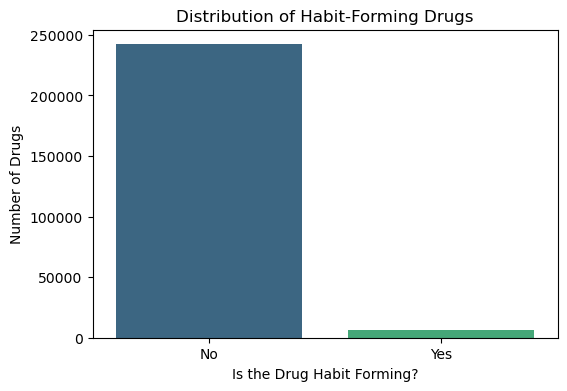

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x='Habit Forming', data=df, palette='viridis', 
    order=df['Habit Forming'].value_counts().index,hue='Habit Forming',legend=False)
plt.title('Distribution of Habit-Forming Drugs')
plt.xlabel('Is the Drug Habit Forming?')
plt.ylabel('Number of Drugs')
plt.show()

#### What are the top 20 most common therapeutic classes?

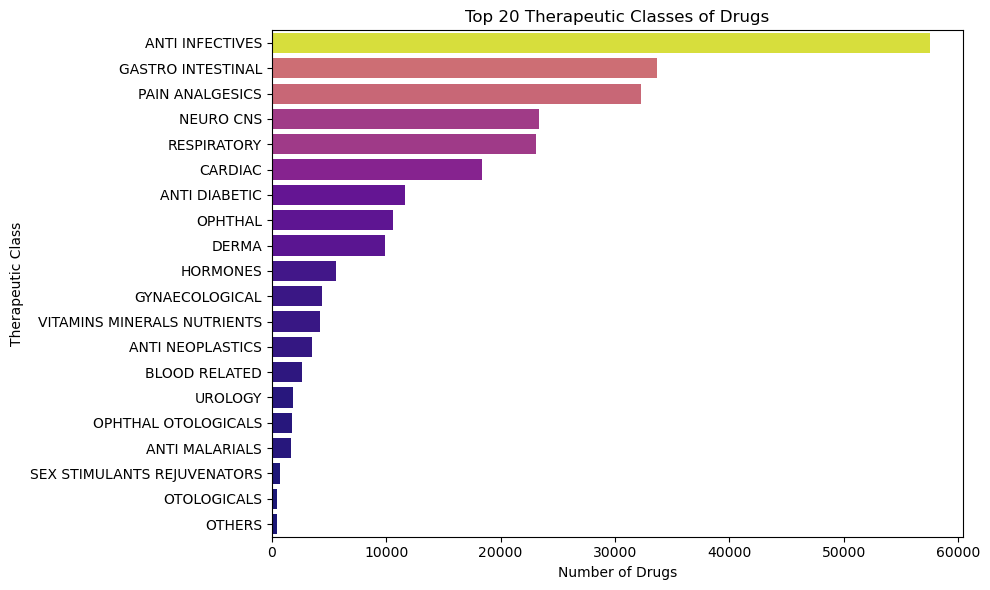

In [66]:
top_20_therapeutic = df['Therapeutic Class'].value_counts().nlargest(20)

plt.figure(figsize=(10,6))
sns.barplot(y=top_20_therapeutic.index, x=top_20_therapeutic.values, 
            palette='plasma',hue=top_20_therapeutic.values,legend=False)
plt.title('Top 20 Therapeutic Classes of Drugs')
plt.xlabel('Number of Drugs')
plt.ylabel('Therapeutic Class')
plt.tight_layout()
plt.show()

#### Side Effect Co-occurrence Analysis (Market Basket Analysis)

In [69]:
from mlxtend.frequent_patterns import apriori, association_rules

# Pre-process 'all_side_effects' into a list of strings for each row
side_effects_list = df['all_side_effects'].str.get_dummies(sep=', ')

# Find frequent itemsets with a minimum support threshold
frequent_itemsets = apriori(side_effects_list, min_support=0.05, use_colnames=True)

# Generate the rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Display rules with high confidence and lift
print(rules.sort_values(by='lift', ascending=False).head(10))

c:\Users\mahes\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                                        antecedents  \
695                    (Diarrhea, Loss of appetite)   
678                   (Vomiting, Heartburn, Nausea)   
689                           (Vomiting, Heartburn)   
684            (Nausea, Diarrhea, Loss of appetite)   
520                           (Vomiting, Heartburn)   
525                    (Diarrhea, Loss of appetite)   
686          (Vomiting, Diarrhea, Loss of appetite)   
687                             (Heartburn, Nausea)   
697                                     (Heartburn)   
676  (Vomiting, Nausea, Diarrhea, Loss of appetite)   

                                        consequents  antecedent support  \
695                   (Vomiting, Heartburn, Nausea)            0.072682   
678                    (Diarrhea, Loss of appetite)            0.065715   
689            (Nausea, Diarrhea, Loss of appetite)            0.066291   
684                           (Vomiting, Heartburn)            0.072549   
520                

#### Hierarchical Visualization of Drug Classes

In [70]:
import plotly.express as px

# Select the relevant columns and drop any rows where all are missing
hierarchy_df = df[['Therapeutic Class', 'Action Class', 'Chemical Class']].dropna(how='all').fillna('Unknown')

# Create the sunburst chart
fig = px.sunburst(
    hierarchy_df,
    path=['Therapeutic Class', 'Action Class', 'Chemical Class'],
    title='Hierarchical Distribution of Drug Classes'
)

fig.show()

#### Drug Name Analysis with n-grams

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Analyze 2-word sequences (bigrams) in drug names
vec = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bigrams = vec.fit_transform(df['name'])
bigram_counts = pd.DataFrame(zip(vec.get_feature_names_out(), bigrams.sum(axis=0).tolist()[0]), columns=['Bigram', 'Count'])

# Display the most common drug name bigrams
print(bigram_counts.sort_values(by='Count', ascending=False).head(10))

                 Bigram  Count
2594       500mg tablet  11476
479         10mg tablet   9538
2837         5mg tablet   9114
1221       200mg tablet   7796
1533       250mg tablet   6775
374        100mg tablet   5306
153019  oral suspension   5014
67440         dry syrup   4893
127992        mg tablet   4747
1303        20mg tablet   4745


#### Statistical Association Testing (Chi-Squared Test)

In [72]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['Therapeutic Class'], df['Habit Forming'])

# Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Squared Statistic: {chi2}")
print(f"P-value: {p}")

if p < 0.05:
    print("\nThe relationship is statistically significant.")
else:
    print("\nThe relationship is not statistically significant.")

Chi-Squared Statistic: 26183.61117995222
P-value: 0.0

The relationship is statistically significant.


#### Use Case Analysis (Targeting the Model)

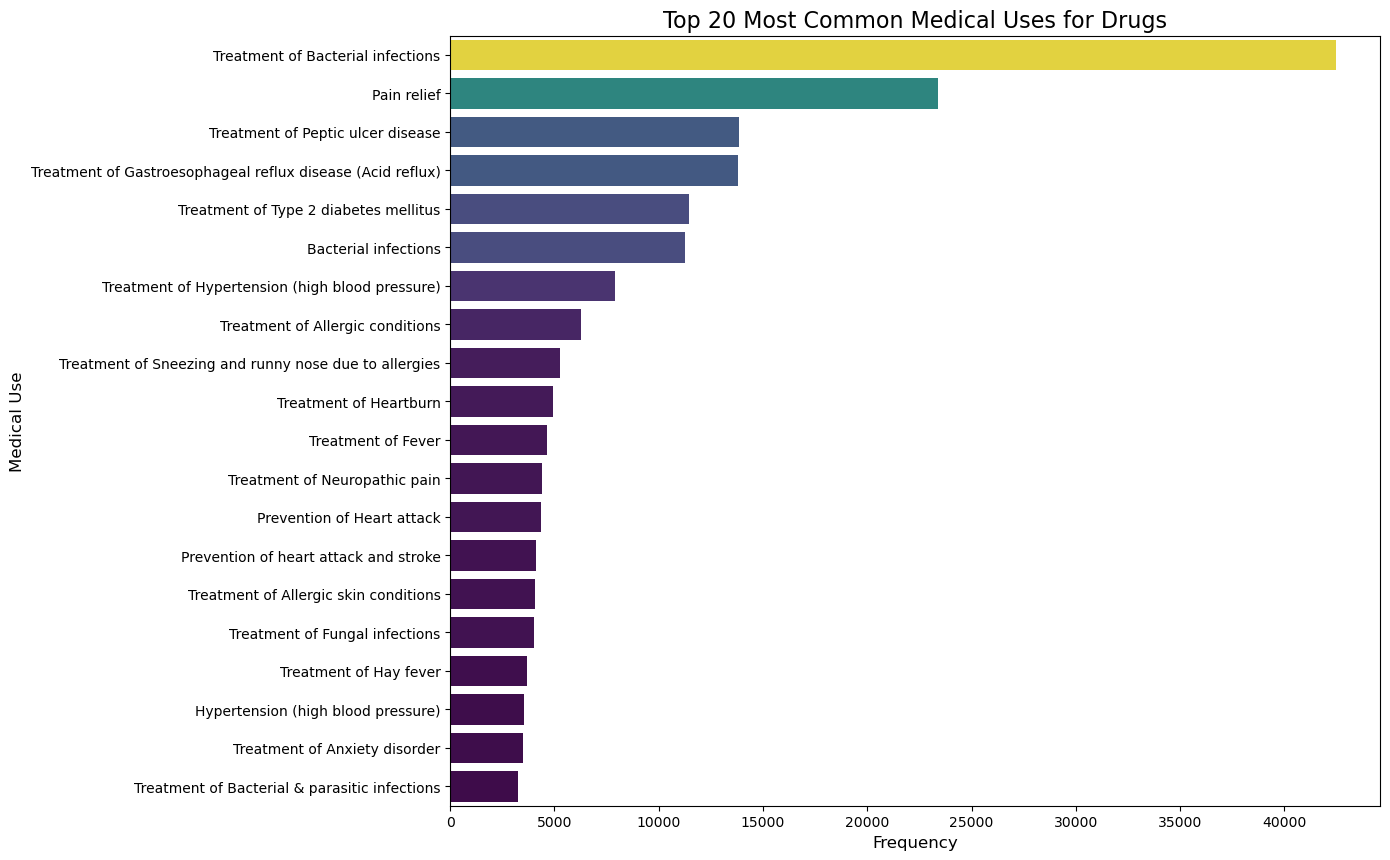

In [74]:
from collections import Counter

uses_counter = Counter(item.strip() for sublist in df[df['all_uses'] != 'Not specified']['all_uses'].str.split(',') for item in sublist)

most_common_uses = pd.DataFrame(uses_counter.most_common(20), columns=['Use', 'Frequency'])

plt.figure(figsize=(12, 10))
sns.barplot(y='Use', x='Frequency', data=most_common_uses, 
        palette='viridis',hue='Frequency',legend=False)
plt.title('Top 20 Most Common Medical Uses for Drugs', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Medical Use', fontsize=12)
plt.show()

#### Feature-Level Vocabulary Analysis

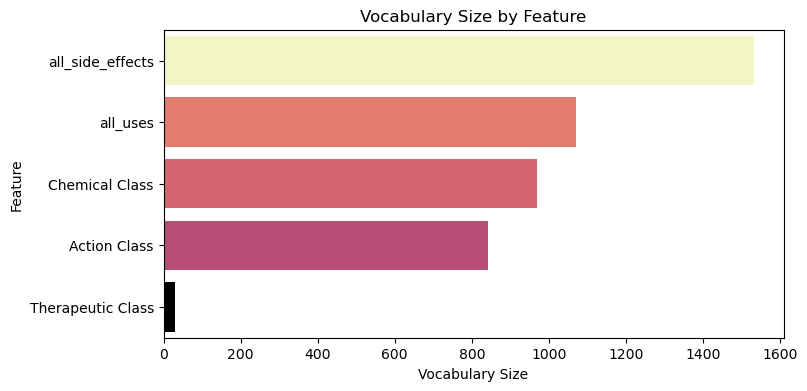

In [76]:
features_to_analyze = ['Therapeutic Class', 'Action Class', 'Chemical Class', 'all_side_effects', 'all_uses']
vocab_sizes = {}

for feature in features_to_analyze:
    vocabulary = set(word for entry in df[feature].dropna() for word in entry.split())
    vocab_sizes[feature] = len(vocabulary)

vocab_df = pd.DataFrame(list(vocab_sizes.items()), columns=['Feature', 'Vocabulary Size']).sort_values(by='Vocabulary Size', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x='Vocabulary Size', y='Feature', data=vocab_df, 
        palette='magma',hue='Vocabulary Size',legend=False)
plt.title('Vocabulary Size by Feature')
plt.show()

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_cols_by_prefix(df, prefix):
    return [col for col in df.columns if col.startswith(prefix)]

side_effect_cols = get_cols_by_prefix(df, 'sideEffect')
use_cols = get_cols_by_prefix(df, 'use')

df['all_side_effects'] = df[side_effect_cols].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)
df['all_uses'] = df[use_cols].apply(
    lambda row: ', '.join(row.dropna().astype(str)), axis=1
)

df['all_side_effects'] = df['all_side_effects'].replace('', np.nan)
df['all_uses'] = df['all_uses'].replace('', np.nan)

df.drop(columns=side_effect_cols + use_cols, inplace=True)
df.dropna(subset=['Therapeutic Class'], inplace=True)
fill_values = {
    'all_uses': 'Not specified',
    'all_side_effects': 'None reported',
    'Habit Forming': 'Unknown'
}
df.fillna(value=fill_values, inplace=True)
df.dropna(subset=['name'], inplace=True)

features = ['Therapeutic Class', 'Action Class', 'Chemical Class', 'all_side_effects', 'all_uses']
for feature in features:
    df[feature] = df[feature].fillna('')

def create_soup(x):
    return (x['Therapeutic Class'] + ' ' +
            x['Action Class'] + ' ' +
            x['Chemical Class'] + ' ' +
            x['all_side_effects'] + ' ' +
            x['all_uses'])

df['soup'] = df.apply(create_soup, axis=1)

print("Feature 'soup' created successfully. Here's an example:")
print(df.iloc[0]['soup'])

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['soup'])

print("\nTF-IDF matrix created successfully.")
print(f"Shape of the matrix: {tfidf_matrix.shape}")

C:\Users\mahes\AppData\Local\Temp\ipykernel_35448\181076883.py:16: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\mahes\AppData\Local\Temp\ipykernel_35448\181076883.py:17: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Feature 'soup' created successfully. Here's an example:
ANTI INFECTIVES   None reported Not specified

TF-IDF matrix created successfully.
Shape of the matrix: (248149, 1402)


In [80]:
df

,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,Chemical Class,Habit Forming,Therapeutic Class,Action Class,all_side_effects,all_uses,soup
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,,No,ANTI INFECTIVES,,None reported,Not specified,ANTI INFECTIVES None reported Not specified
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Macrolides,No,ANTI INFECTIVES,Macrolides,None reported,Not specified,ANTI INFECTIVES Macrolides Macrolides None rep...
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,,No,RESPIRATORY,,None reported,Not specified,RESPIRATORY None reported Not specified
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation),None reported,Not specified,RESPIRATORY H1 Antihistaminics (second Generat...
4,5,avil 25 tablet,Eralet 25mg Tablet,None,None,None,None,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation),None reported,Not specified,RESPIRATORY H1 Antihistaminics (First Generati...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248213,248214,zestrain 100mg/325mg/250mg tablet mr,Aclotec MR 100mg/325mg/250mg Tablet,SAMONEC MR TABLET,Uniclof 100mg/325mg/250mg Tablet MR,Macito 100mg/325mg/250mg Tablet MR,Rumatin 100mg/325mg/250mg Tablet MR,,No,PAIN ANALGESICS,,None reported,Not specified,PAIN ANALGESICS None reported Not specified
248214,248215,zoxinace 200mg tablet sr,Algic 200mg Tablet SR,Topnac 200mg Tablet SR,Kindac 200mg Tablet SR,Ultranac 200mg Tablet SR,Bignac 200mg Tablet SR,Dichlorobenzenes Derivative,No,PAIN ANALGESICS,NSAID's- Non-Selective COX 1&2 Inhibitors (ace...,None reported,Not specified,PAIN ANALGESICS NSAID's- Non-Selective COX 1&2...
248215,248216,zivex 25mg tablet,HD Zine 25mg Tablet,Hydrocas 25mg Tablet,Hyzox 25 Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation),None reported,Not specified,RESPIRATORY H1 Antihistaminics (First Generati...
248216,248217,zi fast 500mg injection,Zycin 500mg Injection,Aziwok 500mg Injection,Azirow 500mg Injection,Toracin 500mg Injection,Azymed 500mg Injection,Macrolides,No,ANTI INFECTIVES,Macrolides,None reported,Not specified,ANTI INFECTIVES Macrolides Macrolides None rep...


In [ ]:
df.drop(columns=['all_side_effects', 'all_uses'], inplace=True)

In [83]:
df

,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,Chemical Class,Habit Forming,Therapeutic Class,Action Class,soup
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,,No,ANTI INFECTIVES,,ANTI INFECTIVES None reported Not specified
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Macrolides,No,ANTI INFECTIVES,Macrolides,ANTI INFECTIVES Macrolides Macrolides None rep...
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,,No,RESPIRATORY,,RESPIRATORY None reported Not specified
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation),RESPIRATORY H1 Antihistaminics (second Generat...
4,5,avil 25 tablet,Eralet 25mg Tablet,None,None,None,None,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation),RESPIRATORY H1 Antihistaminics (First Generati...
...,...,...,...,...,...,...,...,...,...,...,...,...
248213,248214,zestrain 100mg/325mg/250mg tablet mr,Aclotec MR 100mg/325mg/250mg Tablet,SAMONEC MR TABLET,Uniclof 100mg/325mg/250mg Tablet MR,Macito 100mg/325mg/250mg Tablet MR,Rumatin 100mg/325mg/250mg Tablet MR,,No,PAIN ANALGESICS,,PAIN ANALGESICS None reported Not specified
248214,248215,zoxinace 200mg tablet sr,Algic 200mg Tablet SR,Topnac 200mg Tablet SR,Kindac 200mg Tablet SR,Ultranac 200mg Tablet SR,Bignac 200mg Tablet SR,Dichlorobenzenes Derivative,No,PAIN ANALGESICS,NSAID's- Non-Selective COX 1&2 Inhibitors (ace...,PAIN ANALGESICS NSAID's- Non-Selective COX 1&2...
248215,248216,zivex 25mg tablet,HD Zine 25mg Tablet,Hydrocas 25mg Tablet,Hyzox 25 Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation),RESPIRATORY H1 Antihistaminics (First Generati...
248216,248217,zi fast 500mg injection,Zycin 500mg Injection,Aziwok 500mg Injection,Azirow 500mg Injection,Toracin 500mg Injection,Azymed 500mg Injection,Macrolides,No,ANTI INFECTIVES,Macrolides,ANTI INFECTIVES Macrolides Macrolides None rep...


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
def get_cols_by_prefix(df, prefix):
    return [col for col in df.columns if col.startswith(prefix)]

side_effect_cols = get_cols_by_prefix(df, 'sideEffect')
use_cols = get_cols_by_prefix(df, 'use')
substitute_cols = get_cols_by_prefix(df, 'substitute')


df['all_side_effects'] = df[side_effect_cols].apply(lambda row: ', '.join(row.dropna().astype(str)), axis=1)
df['all_uses'] = df[use_cols].apply(lambda row: ', '.join(row.dropna().astype(str)), axis=1)
df['all_substitutes'] = df[substitute_cols].apply(lambda row: ', '.join(row.dropna().astype(str)), axis=1)


df.drop(columns=side_effect_cols + use_cols + substitute_cols, inplace=True)

df.dropna(subset=['Therapeutic Class'], inplace=True)
fill_values = {
    'all_uses': 'Not specified',
    'all_side_effects': 'None reported',
    'all_substitutes': 'None available',
    'Habit Forming': 'Unknown'
}
df.fillna(value=fill_values, inplace=True)
df.dropna(subset=['name'], inplace=True)
df = df.reset_index(drop=True)

features = ['Therapeutic Class', 'Action Class', 'Chemical Class', 'all_side_effects', 'all_uses']
for feature in features:
    df[feature] = df[feature].fillna('')
df['soup'] = df.apply(lambda x: ' '.join([x[f] for f in features]), axis=1)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['soup'])

print(f"TF-IDF matrix created with shape: {tfidf_matrix.shape}")

TF-IDF matrix created with shape: (248149, 1400)


In [ ]:
# Create the name-to-index mapping (this line is correct)
indices = pd.Series(df.index, index=df['name']).drop_duplicates()

def get_recommendations_memory_efficient(drug_name, tfidf_matrix=tfidf_matrix):
    """
    This function takes a drug name and the TF-IDF matrix, and returns
    recommendations by calculating similarity scores on-the-fly.
    """
    # Check if the drug is in our dataset
    if drug_name not in indices:
        return f"Sorry, the drug '{drug_name}' was not found in the dataset."

    # --- THIS IS THE FIX ---
    # Get the index (or indices) of the input drug
    idx = indices[drug_name]

    # If the name is duplicated, idx will be a Series. We take the first one.
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    # ----------------------

    # Get the TF-IDF vector for the specific drug
    drug_vector = tfidf_matrix[idx]

    # Compute the cosine similarity of this ONE drug against ALL others
    sim_scores = linear_kernel(drug_vector, tfidf_matrix).flatten()

    # Get the indices of the top 5 most similar drugs (excluding the drug itself)
    similar_drug_indices = sim_scores.argsort()[-6:-1][::-1]

    # Return the names of the top 5 most similar drugs
    return df['name'].iloc[similar_drug_indices]

# Test Case 1: A common antibiotic
print("Recommendations for 'augmentin 625 duo tablet':")
display(get_recommendations_memory_efficient('augmentin 625 duo tablet'))

# Test Case 2: A common antihistamine for allergies
print("\nRecommendations for 'allegra 120mg tablet':")
display(get_recommendations_memory_efficient('allegra 120mg tablet'))

Recommendations for 'augmentin 625 duo tablet':


70794          duet 400mg/57mg tablet
222700    tozar cv 500mg/500mg tablet
71002         doxynik lb 100mg tablet
70961             doloxy-cv lb tablet
70956               doxyred-lb tablet
Name: name, dtype: object


Recommendations for 'allegra 120mg tablet':


146977    montegra 180mg tablet
95149          fx 24 suspension
13921       alfine 180mg tablet
1650        algrot 120mg tablet
96406       ffd oral suspension
Name: name, dtype: object